In [91]:
using Random
using Distributions
using LinearAlgebra

# Set parameters
n = 7
mInd = 1
μ = 1
σ = 5
nIter = 40000
sampIter = 1000  # Increase as needed
cMax = 1000
seed = 2

Random.seed!(seed)

# Helper function to compute the adjugate of a matrix
function adjugate(A)
    n = size(A, 1)
    adj = zeros(eltype(A), n, n)
    for i in 1:n, j in 1:n
        # Minor of A with row j and column i removed (note the transpose for adjugate)
        minor = A[setdiff(1:n, j), setdiff(1:n, i)]
        adj[i, j] = (-1)^(i + j) * det(minor)
    end
    return adj
end

# Set up containers
kValsList = []
countList = []
signsList = []

for sample = 1:nIter  # Increase as needed
    # Sample k matrix (symmetric lognormal)
    dist = LogNormal(μ, σ)
    kValsT = rand(dist, n, n)
    for i in 1:n, j in 1:n
        if i > j
            kValsT[i, j] = kValsT[j, i]
        end
    end
    kInvVals = 1.0 ./ kValsT

    signList = Set{Vector{Int}}()
    for _ in 1:sampIter
        cEvs = rand(Uniform(0, cMax), n)
        # Build Qf and Qd numerically
        Qf = [cEvs[i] * kInvVals[i, j] for i in 1:n, j in 1:n]
        Qd = Diagonal([1 + sum(kInvVals[i, j] * cEvs[j] for j in 1:n) for i in 1:n])
        Qmat = Qf .+ Qd

        # Compute adjugate numerically
        QmatAdj = adjugate(Qmat)

        # Extract column mInd
        col = QmatAdj[:, mInd]

        # Record sign pattern
        signs = sign.(col)
        push!(signList, signs)
    end

    push!(kValsList, kValsT)
    push!(countList, length(signList))
    push!(signsList, signList)
end

# Example: print the number of unique sign patterns for each sample
println(countList)

In [92]:
maximum(countList)

23

In [93]:
indices15 = findall(x -> x == 15, countList)
indMax = findmax(countList)[2]
ind = indices15[1]
#print(countList[indMax])
#signsList[indMax]


158

In [96]:
kValsT = kValsList[ind]

7×7 Matrix{Float64}:
  68.2915       237.564          0.00529737  …     0.0171624    4.83737
 237.564       4593.83           0.628162        191.312        0.000388286
   0.00529737     0.628162     610.516             0.00253699  71.0586
   0.153701       0.0117678      6.34385         303.119        0.0280639
   7.80879       13.0064         0.133808         24.3524       0.27708
   0.0171624    191.312          0.00253699  …  1159.84         0.33351
   4.83737        0.000388286   71.0586            0.33351      1.5441

In [108]:
# Set parameters
n = 7
mInd = 1
μ = 1
σ = 5
sampIter = 5000000  # Increase as needed
cMax = 1000


# Sample k matrix (symmetric lognormal)
kValsT = kValsList[indMax]
#kValsT[1,1] = kValsT[1,1] #+ 1
kInvVals = 1.0 ./ kValsT

signList = Set{Vector{Int}}()
for _ in 1:sampIter
    cEvs = rand(Uniform(0, cMax), n)
    # Build Qf and Qd numerically
    Qf = [cEvs[i] * kInvVals[i, j] for i in 1:n, j in 1:n]
    Qd = Diagonal([1 + sum(kInvVals[i, j] * cEvs[j] for j in 1:n) for i in 1:n])
    Qmat = Qf .+ Qd

    # Compute adjugate numerically
    QmatAdj = adjugate(Qmat)

    # Extract column mInd
    col = QmatAdj[:, mInd]

    # Record sign pattern
    signs = sign.(col)
    push!(signList, signs)
end



In [109]:
unique(signList)

34-element Vector{Vector{Int64}}:
 [1, 1, -1, -1, -1, -1, -1]
 [1, 1, -1, -1, 1, -1, 1]
 [1, -1, 1, -1, 1, 1, -1]
 [1, -1, 1, 1, -1, -1, 1]
 [1, 1, 1, 1, 1, -1, -1]
 [1, -1, -1, -1, -1, -1, 1]
 [1, 1, -1, -1, 1, -1, -1]
 [1, -1, 1, 1, -1, -1, -1]
 [1, -1, -1, -1, -1, -1, -1]
 [1, -1, -1, -1, 1, -1, 1]
 ⋮
 [1, 1, -1, 1, 1, -1, -1]
 [1, -1, 1, -1, 1, -1, -1]
 [1, -1, 1, -1, -1, 1, 1]
 [1, 1, 1, 1, -1, -1, 1]
 [1, -1, 1, -1, -1, 1, -1]
 [1, 1, -1, -1, -1, -1, 1]
 [1, -1, -1, 1, -1, 1, 1]
 [1, 1, 1, 1, -1, -1, -1]
 [1, -1, 1, -1, 1, 1, 1]

In [46]:
signList

Set{Vector{Int64}} with 16 elements:
  [1, -1, 1, 1, -1, -1]
  [1, 1, -1, -1, 1, -1]
  [1, 1, 1, -1, -1, 1]
  [1, 1, -1, 1, 1, -1]
  [1, -1, -1, -1, -1, 1]
  [1, 1, 1, -1, -1, -1]
  [1, -1, 1, 1, 1, -1]
  [1, -1, -1, -1, -1, -1]
  [1, 1, 1, 1, -1, -1]
  [1, -1, -1, 1, -1, -1]
  [1, -1, -1, -1, 1, 1]
  [1, 1, -1, -1, -1, 1]
  [1, -1, 1, -1, -1, 1]
  [1, -1, -1, 1, 1, -1]
  [1, -1, 1, -1, -1, -1]
  [1, 1, -1, -1, 1, 1]

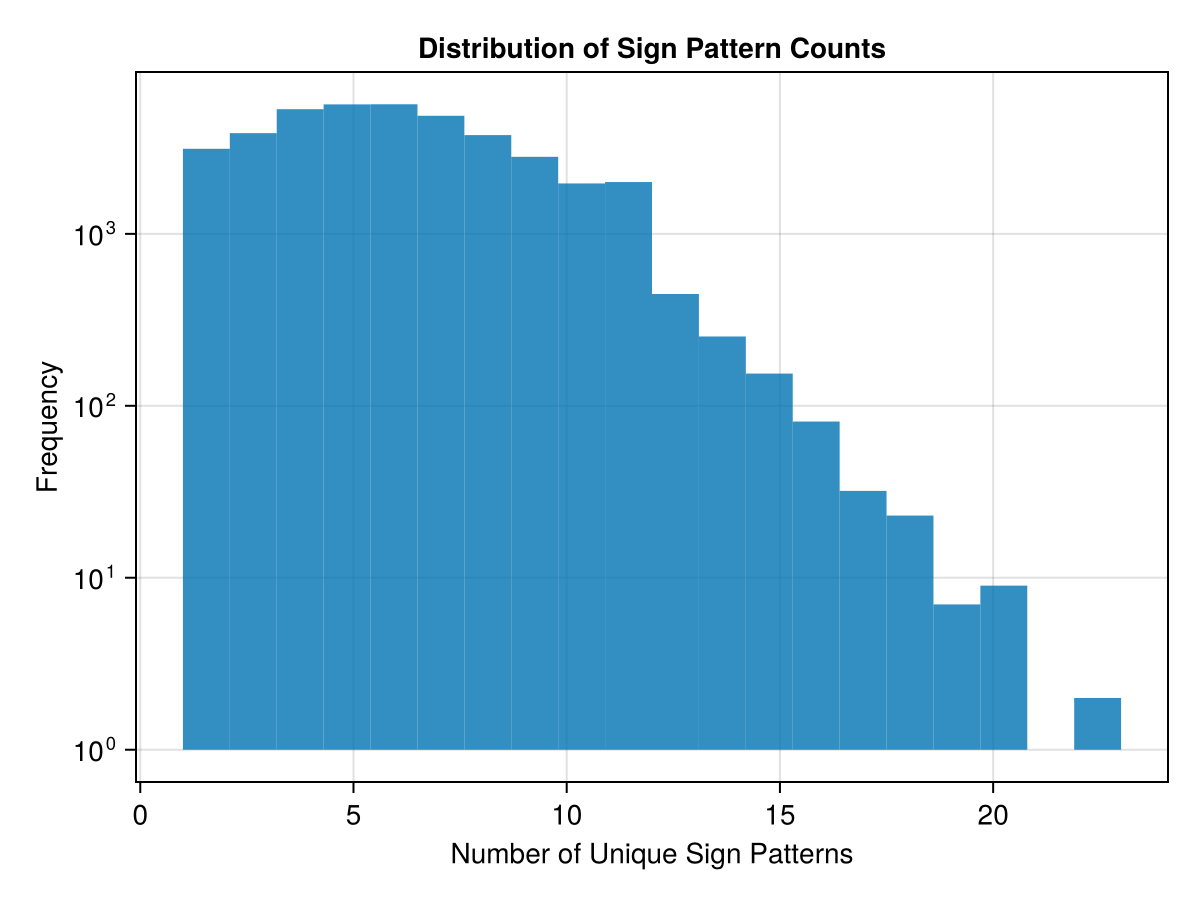

In [101]:
using CairoMakie
hist(countList, bins=20, axis=(;
    xlabel="Number of Unique Sign Patterns",
    ylabel="Frequency",
    title="Distribution of Sign Pattern Counts",
    yscale=log10
))

In [ ]:
1, 3, 6, 10 